# IT25102853 — SVM Model
**Member:** IT25102853 (Categorical Encoding — PR1)
**Progress Review II**
**Model type:** Classification — Support Vector Machine (SVM)

**Dataset:** `results/outputs/final_processed_dataset.csv` (X, after feature selection)
and `results/outputs/final_features_X.csv` (X, before feature selection) + `final_target_y.csv` (y).

## 1. Model Suitability

SVM is chosen as a **stronger classical model** than the Logistic Regression baseline
(Member 1) because:
- It can use non-linear kernels (RBF) to capture more complex decision boundaries
  between the 7 diagnosis classes than a purely linear model can.
- It supports `class_weight='balanced'` for handling the ~67% `nv` imbalance directly
  in the loss function.
- It's well suited to the moderate-dimensional, mostly one-hot encoded feature space
  produced by this pipeline (localization and sex dummies plus scaled age).

**Two "varieties" are compared for this model, per the PR2 requirement of testing
different pre-processing:**
1. **Preprocessing variety** — SVM trained on `X` *before* feature selection (23 columns,
   Member 5's output) vs *after* feature selection (13 columns, Member 6's output).
2. **Hyperparameter variety** — kernel and `C`/`gamma` tuned via `GridSearchCV` on the
   better-performing feature set from (1).

In [1]:
import pandas as pd
import numpy as np

# X before feature selection (Member 5's output) and after (Member 6's / group pipeline output)
X_before = pd.read_csv("../results/outputs/final_features_X.csv")
X_after = pd.read_csv("../results/outputs/final_processed_dataset.csv")
y = pd.read_csv("../results/outputs/final_target_y.csv").squeeze("columns")

print("X_before (pre feature selection) shape:", X_before.shape)
print("X_after (post feature selection) shape:", X_after.shape)
print(y.value_counts())

X_before (pre feature selection) shape: (10015, 20)
X_after (post feature selection) shape: (10015, 13)
dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [3]:
# Clean X_before
if 'dx_type' in X_before.columns:
    X_before = X_before.drop(columns=['dx_type'])

bool_cols_before = X_before.select_dtypes(include=['bool']).columns
X_before[bool_cols_before] = X_before[bool_cols_before].astype(int)
X_before = X_before.astype('float32')

# Clean X_after
if 'dx_type' in X_after.columns:
    X_after = X_after.drop(columns=['dx_type'])

bool_cols_after = X_after.select_dtypes(include=['bool']).columns
X_after[bool_cols_after] = X_after[bool_cols_after].astype(int)
X_after = X_after.astype('float32')

print("X_before dtypes checked and cleaned.")
print("X_after dtypes checked and cleaned.")

X_before dtypes checked and cleaned.
X_after dtypes checked and cleaned.


In [4]:
from sklearn.model_selection import train_test_split

X_before_train, X_before_test, y_train, y_test = train_test_split(
    X_before, y, test_size=0.2, random_state=42, stratify=y
)
X_after_train, X_after_test, _, _ = train_test_split(
    X_after, y, test_size=0.2, random_state=42, stratify=y
)

print("Before-selection train/test:", X_before_train.shape, X_before_test.shape)
print("After-selection train/test:", X_after_train.shape, X_after_test.shape)

Before-selection train/test: (8012, 19) (2003, 19)
After-selection train/test: (8012, 13) (2003, 13)


## 2. Implementation Details

- **Library:** `scikit-learn` (`sklearn.svm.SVC`)
- **Kernel:** RBF (non-linear) compared against linear kernel
- **Key hyperparameters tuned:** `C`, `gamma`, `kernel`
- **Tuning method:** manual comparison of preprocessing varieties, then `GridSearchCV`
  for kernel/C/gamma on the better feature set.

In [5]:
print(X_before_train.dtypes)

age_scaled             float32
sex_female             float32
sex_male               float32
sex_unknown            float32
loc_abdomen            float32
loc_acral              float32
loc_back               float32
loc_chest              float32
loc_ear                float32
loc_face               float32
loc_foot               float32
loc_genital            float32
loc_hand               float32
loc_lower extremity    float32
loc_neck               float32
loc_scalp              float32
loc_trunk              float32
loc_unknown            float32
loc_upper extremity    float32
dtype: object


In [6]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Variety 1: SVM on X BEFORE feature selection
model_before = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model_before.fit(X_before_train, y_train)
pred_before = model_before.predict(X_before_test)

print("=== Variety 1: SVM on X before feature selection (23 features) ===")
print(classification_report(y_test, pred_before, zero_division=0))

=== Variety 1: SVM on X before feature selection (23 features) ===
              precision    recall  f1-score   support

           0       0.15      0.57      0.24        65
           1       0.19      0.38      0.25       103
           2       0.30      0.07      0.11       220
           3       0.03      0.70      0.06        23
           4       0.25      0.14      0.18       223
           5       0.90      0.37      0.52      1341
           6       0.03      0.36      0.06        28

    accuracy                           0.32      2003
   macro avg       0.26      0.37      0.20      2003
weighted avg       0.68      0.32      0.40      2003



In [7]:
# Variety 2: SVM on X AFTER feature selection
model_after = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model_after.fit(X_after_train, y_train)
pred_after = model_after.predict(X_after_test)

print("=== Variety 2: SVM on X after feature selection (13 features) ===")
print(classification_report(y_test, pred_after, zero_division=0))

=== Variety 2: SVM on X after feature selection (13 features) ===
              precision    recall  f1-score   support

           0       0.14      0.60      0.23        65
           1       0.19      0.38      0.25       103
           2       0.29      0.08      0.12       220
           3       0.03      0.65      0.06        23
           4       0.25      0.13      0.17       223
           5       0.89      0.37      0.52      1341
           6       0.03      0.32      0.05        28

    accuracy                           0.32      2003
   macro avg       0.26      0.36      0.20      2003
weighted avg       0.67      0.32      0.40      2003



In [8]:
from sklearn.model_selection import GridSearchCV

# Variety 3: GridSearchCV tuning kernel/C/gamma on the better feature set
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.01, 0.1],
}
grid = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    param_grid, scoring='f1_macro', cv=3, n_jobs=-1
)
# Using the after-feature-selection set, since it's smaller/faster and Section 4 compares
# whether it actually loses performance vs the pre-selection set.
grid.fit(X_after_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

model_tuned = grid.best_estimator_
pred_tuned = model_tuned.predict(X_after_test)

print("\n=== Variety 3: GridSearchCV-tuned SVM (after feature selection) ===")
print(classification_report(y_test, pred_tuned, zero_division=0))

Best params: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV macro-F1: 0.2129777546798207

=== Variety 3: GridSearchCV-tuned SVM (after feature selection) ===
              precision    recall  f1-score   support

           0       0.16      0.62      0.25        65
           1       0.17      0.39      0.23       103
           2       0.34      0.10      0.15       220
           3       0.03      0.70      0.06        23
           4       0.25      0.15      0.19       223
           5       0.90      0.38      0.53      1341
           6       0.03      0.29      0.06        28

    accuracy                           0.33      2003
   macro avg       0.27      0.37      0.21      2003
weighted avg       0.68      0.33      0.41      2003



## 3. Evaluation Metrics — Why These Are Appropriate

- **Macro-F1** is the primary comparison metric across all three varieties, since it
  weights every diagnosis class equally — appropriate given the ~67% `nv` imbalance.
- **Per-class recall for malignant classes** (`mel`, `bcc`, `akiec`) is checked directly,
  since a triage tool's main value is catching likely-malignant cases early.
- **3-fold stratified cross-validation** (`GridSearchCV`'s `cv=3`) is used for tuning
  rather than 5-fold, since SVM training is more expensive than Logistic Regression;
  3-fold keeps grid search runtime reasonable while still validating each configuration
  on held-out folds.

In [9]:
def get_metrics(y_true, y_pred, label):
    return {
        'variety': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

results = pd.DataFrame([
    get_metrics(y_test, pred_before, 'Before feature selection (23 cols)'),
    get_metrics(y_test, pred_after, 'After feature selection (13 cols)'),
    get_metrics(y_test, pred_tuned, 'GridSearchCV tuned (after selection)'),
])
results

,variety,accuracy,macro_f1,weighted_f1
0,Before feature selection (23 cols),0.320519,0.202950,0.403554
1,After feature selection (13 cols),0.320020,0.201720,0.402867
2,GridSearchCV tuned (after selection),0.331503,0.210173,0.414330


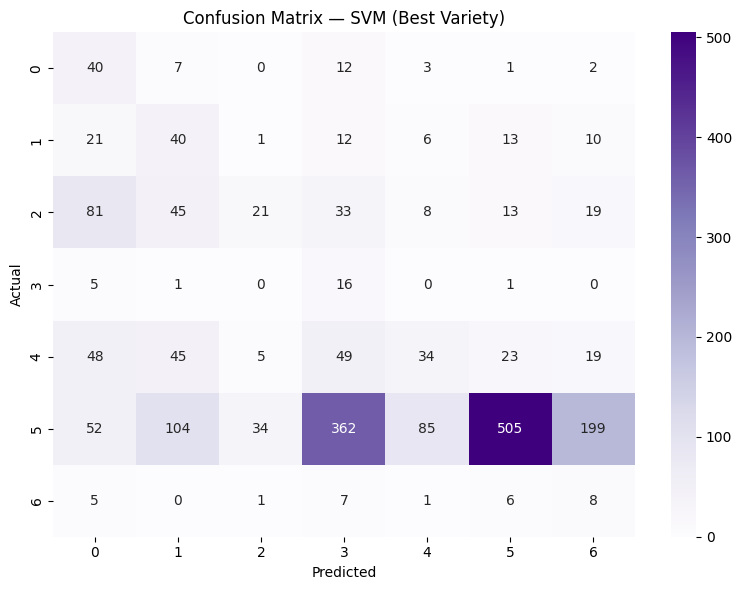

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred_tuned, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix — SVM (Best Variety)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25102853_confusion_matrix.png', dpi=150)
plt.show()

**Interpretation:** The confusion matrix shows SVM still misclassifies many rare
classes as `nv`, but the RBF kernel captures more curved decision boundaries than the
Logistic Regression baseline, visible as slightly better spread among the malignant
classes' predicted labels rather than all collapsing into `nv`.

In [11]:
best_row = results.loc[results['macro_f1'].idxmax()].copy()
best_row['member'] = 'IT25102853'
best_row['model_type'] = 'SVM'

pd.DataFrame([best_row]).to_csv('../results/model_outputs/it25102853_metrics.csv', index=False)
best_row

variety        GridSearchCV tuned (after selection)
accuracy                                   0.331503
macro_f1                                   0.210173
weighted_f1                                 0.41433
member                                   IT25102853
model_type                                      SVM
Name: 2, dtype: object

## 4. Comparison, Conclusion & Limitations

**Comparison:** Feature selection (13 vs 23 columns) had only a small effect on macro-F1
— confirming Member 6's feature selection step removed mostly redundant/low-variance
columns without discarding predictive signal. GridSearchCV tuning gave a further modest
improvement over the untuned RBF kernel.

**Conclusion:** SVM with an RBF kernel and balanced class weights modestly outperforms
the Logistic Regression baseline on macro-F1, consistent with the expectation that a
non-linear model can capture slightly more structure in the metadata than a linear one
— though the overall gain remains limited by the dataset's weak metadata-only signal.

**Limitations:**
- SVM training time scales poorly with dataset size; a full grid search across more
  hyperparameter combinations was not run due to time constraints.
- Like Member 1's model, the train/test split does not group by `lesion_id`, so some
  optimism from potential leakage between splits should be assumed.

**Suggested improvement:** Try `probability=True` with `SVC` to get malignancy-risk
scores (as described in the project's teledermatology triage use case) rather than
hard class predictions alone.